Shape: (297, 14)

Columns:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'condition']

Missing values:
age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0
ca           0
thal         0
condition    0
dtype: int64

Best k selected by silhouette score: 2


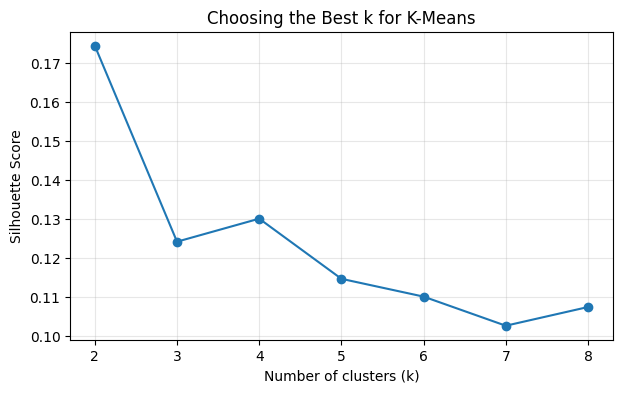


Original training shape: (237, 13)
Hybrid training shape: (237, 15)

Best SVM Parameters:
{'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}
Best CV F1-score: 0.7975

Hybrid K-Means + SVM Results
----------------------------------------
Accuracy : 0.9167
Precision: 1.0
Recall   : 0.8214
F1-score : 0.902
ROC-AUC  : 0.9319

Classification Report:
              precision    recall  f1-score   support

           0     0.8649    1.0000    0.9275        32
           1     1.0000    0.8214    0.9020        28

    accuracy                         0.9167        60
   macro avg     0.9324    0.9107    0.9147        60
weighted avg     0.9279    0.9167    0.9156        60



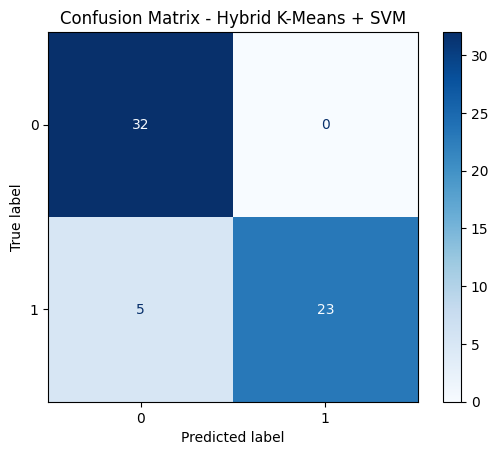


Baseline SVM Results
----------------------------------------
Accuracy : 0.8667
Precision: 1.0
Recall   : 0.7143
F1-score : 0.8333
ROC-AUC  : 0.9263

Comparison Table:
                  Model  Accuracy  Precision  Recall  F1-score  ROC-AUC
0          Baseline SVM    0.8667        1.0  0.7143    0.8333   0.9263
1  Hybrid K-Means + SVM    0.9167        1.0  0.8214    0.9020   0.9319


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.svm import SVC
from sklearn.metrics import (
    silhouette_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# =========================================================
# 1) Load the dataset
# =========================================================
file_path = "/content/heart_cleveland_upload.csv"   #
df = pd.read_csv(file_path)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

# Target column
target_col = "condition"

X = df.drop(columns=[target_col])
y = df[target_col]

# =========================================================
# 2) Train / Test split
#    Use stratify to preserve class distribution
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# =========================================================
# 3) Feature scaling
#    Important for BOTH K-Means and SVM
# =========================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================================================
# 4) Choose best k for K-Means
#    IMPORTANT:
#    - k-means++ is for centroid initialization
#    - silhouette score is used here to choose k
# =========================================================
k_values = range(2, 9)
silhouette_scores = []

for k in k_values:
    kmeans_temp = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=20,
        random_state=42
    )
    labels_temp = kmeans_temp.fit_predict(X_train_scaled)
    score = silhouette_score(X_train_scaled, labels_temp)
    silhouette_scores.append(score)

best_k = list(k_values)[int(np.argmax(silhouette_scores))]
print("\nBest k selected by silhouette score:", best_k)

# Plot silhouette scores for each k
plt.figure(figsize=(7, 4))
plt.plot(list(k_values), silhouette_scores, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Choosing the Best k for K-Means")
plt.xticks(list(k_values))
plt.grid(True, alpha=0.3)
plt.show()

# =========================================================
# 5) Fit final K-Means using best k and K-Means++
# =========================================================
kmeans = KMeans(
    n_clusters=best_k,
    init="k-means++",
    n_init=20,
    random_state=42
)
kmeans.fit(X_train_scaled)

# =========================================================
# 6) Build hybrid features
#    Better than using only raw cluster labels:
#    use distances to each centroid as extra features
# =========================================================
train_cluster_distances = kmeans.transform(X_train_scaled)
test_cluster_distances = kmeans.transform(X_test_scaled)

X_train_hybrid = np.hstack([X_train_scaled, train_cluster_distances])
X_test_hybrid = np.hstack([X_test_scaled, test_cluster_distances])

print("\nOriginal training shape:", X_train_scaled.shape)
print("Hybrid training shape:", X_train_hybrid.shape)
df.shape()

# =========================================================
# 7) Train and tune SVM with GridSearchCV
# =========================================================
param_grid = {
    "C": [0.1, 1, 10, 50],
    "gamma": ["scale", 0.01, 0.1, 1],
    "kernel": ["rbf", "linear"]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

svm_grid = GridSearchCV(
    estimator=SVC(probability=True),
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

svm_grid.fit(X_train_hybrid, y_train)

best_svm = svm_grid.best_estimator_

print("\nBest SVM Parameters:")
print(svm_grid.best_params_)

print("Best CV F1-score:", round(svm_grid.best_score_, 4))

# =========================================================
# 8) Evaluate hybrid model
# =========================================================
y_pred = best_svm.predict(X_test_hybrid)
y_prob = best_svm.predict_proba(X_test_hybrid)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("\nHybrid K-Means + SVM Results")
print("-" * 40)
print("Accuracy :", round(acc, 4))
print("Precision:", round(prec, 4))
print("Recall   :", round(rec, 4))
print("F1-score :", round(f1, 4))
print("ROC-AUC  :", round(auc, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Hybrid K-Means + SVM")
plt.show()

# =========================================================
# 9) Baseline comparison: plain SVM without K-Means
# =========================================================
baseline_grid = GridSearchCV(
    estimator=SVC(probability=True),
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

baseline_grid.fit(X_train_scaled, y_train)

baseline_svm = baseline_grid.best_estimator_

baseline_pred = baseline_svm.predict(X_test_scaled)
baseline_prob = baseline_svm.predict_proba(X_test_scaled)[:, 1]

baseline_acc = accuracy_score(y_test, baseline_pred)
baseline_prec = precision_score(y_test, baseline_pred)
baseline_rec = recall_score(y_test, baseline_pred)
baseline_f1 = f1_score(y_test, baseline_pred)
baseline_auc = roc_auc_score(y_test, baseline_prob)

print("\nBaseline SVM Results")
print("-" * 40)
print("Accuracy :", round(baseline_acc, 4))
print("Precision:", round(baseline_prec, 4))
print("Recall   :", round(baseline_rec, 4))
print("F1-score :", round(baseline_f1, 4))
print("ROC-AUC  :", round(baseline_auc, 4))

# =========================================================
# 10) Final comparison table
# =========================================================
comparison = pd.DataFrame({
    "Model": ["Baseline SVM", "Hybrid K-Means + SVM"],
    "Accuracy": [baseline_acc, acc],
    "Precision": [baseline_prec, prec],
    "Recall": [baseline_rec, rec],
    "F1-score": [baseline_f1, f1],
    "ROC-AUC": [baseline_auc, auc]
})

print("\nComparison Table:")
print(comparison.round(4))